# Evaluation 1: Prompt 4
You are a writing assistant system for medical reports written in German that can provide corrected versions of the reports You will only respond with the corrected report. Do not provide explanations.

In [30]:
# Imports
import os, json, sys
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import numpy as np
import seaborn as sns

In [31]:
prompt = "prompt4"
gt_id = "gt.45af4a46-d238-4251-b734-d407602299bd"

In [32]:
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from evaluation_tool import duration_t_s_box_plot, multi_histogram, multi_bar_graph, multi_bar_model_graph, semantic_box_plot, violin_plot

In [33]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
prompt_dir = os.path.join(evaluations_dir, prompt)
db_path = os.path.join(data_dir, "DB.db")
gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")

In [34]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [35]:
# Evaluations Unique IDs
unique_ids_gt = [
    "gt.45af4a46-d238-4251-b734-d407602299bd", #Base GT
]

unique_ids_small = [
    "g2s-6-4.f17a95c0-47e5-4beb-a074-17db3b9755a7", #1 gemma2:2b
]

unique_ids_medium = [
    "g2m-7-4.5f22a781-eb79-4e34-99e0-cfacfa4a7b8f", #gemma2:9b
    "l3m-1-4.816d01b2-1d10-4065-9a38-bf0384883ceb", #llama3:8b
    "l31m-3-4.a9d0cfde-6881-4424-ac4d-6d6db6e22698", #llama3.1:8b
    "mm-9-4.d57dd4d3-c8db-43df-839e-94c6371bd042", #mistral-nemo:12b
]

unique_ids_large = [
    "g2l-8-4.2bedd5bb-4bd4-455d-ba18-d0bb214037fc", #gemma2:27b
]

unique_ids_xlarge = [
    "l31xl-4-4.e1291b3b-e452-4b64-8170-eec3ed0b120c", #llama3.1:70b
]

unique_ids_xxlarge = [
    "l31xxl-5-4.3c41eae7-b253-45af-a83e-7a5031d16fec", #llama3.1:405b
    "mxl-11-4.b713aeeb-c613-4d58-a2ac-4a62997db744", #mistral-large:123b
]

In [36]:
# gt_res
with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]

In [37]:
def load_evaluations(unique_ids):
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

In [38]:
res = load_evaluations(unique_ids_medium)
res_all = load_evaluations(unique_ids_small + unique_ids_medium + unique_ids_large + unique_ids_xlarge + unique_ids_xxlarge)

### Duration Metrics

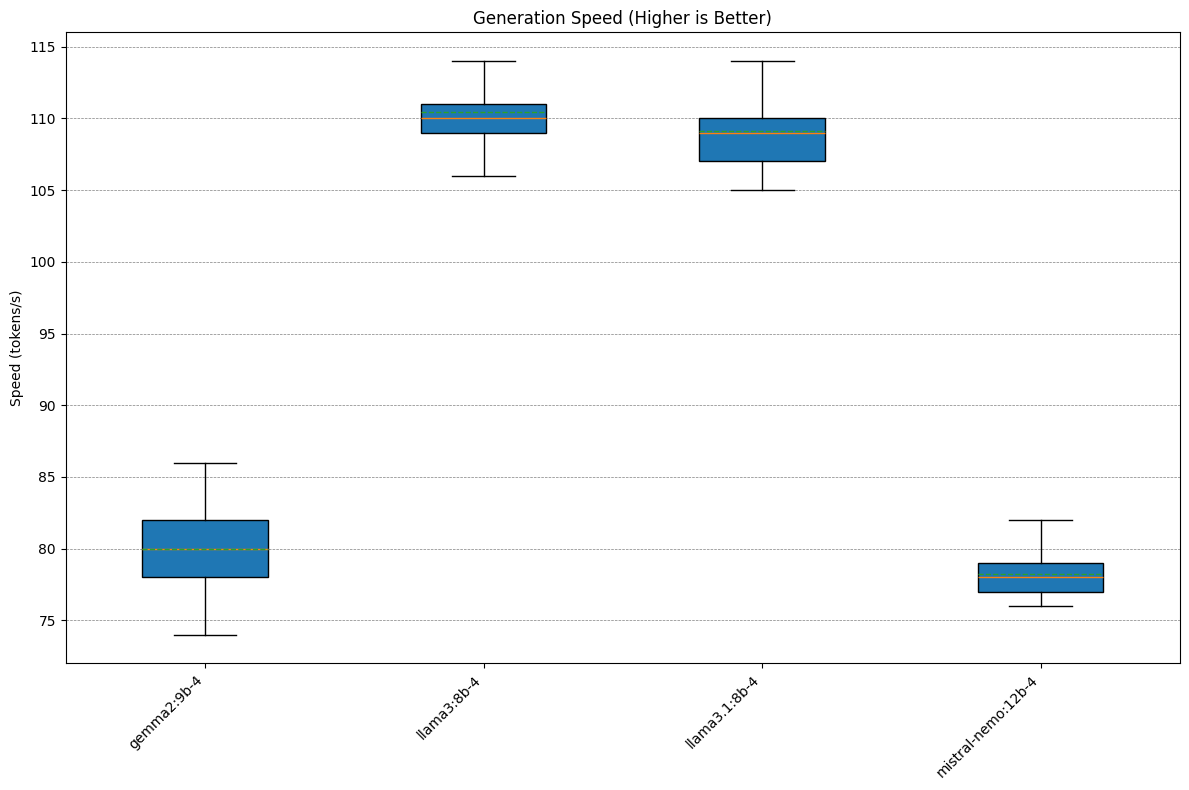

In [39]:
fig, ax = duration_t_s_box_plot(res)

### Difference Metrics

#### SM-Ratio

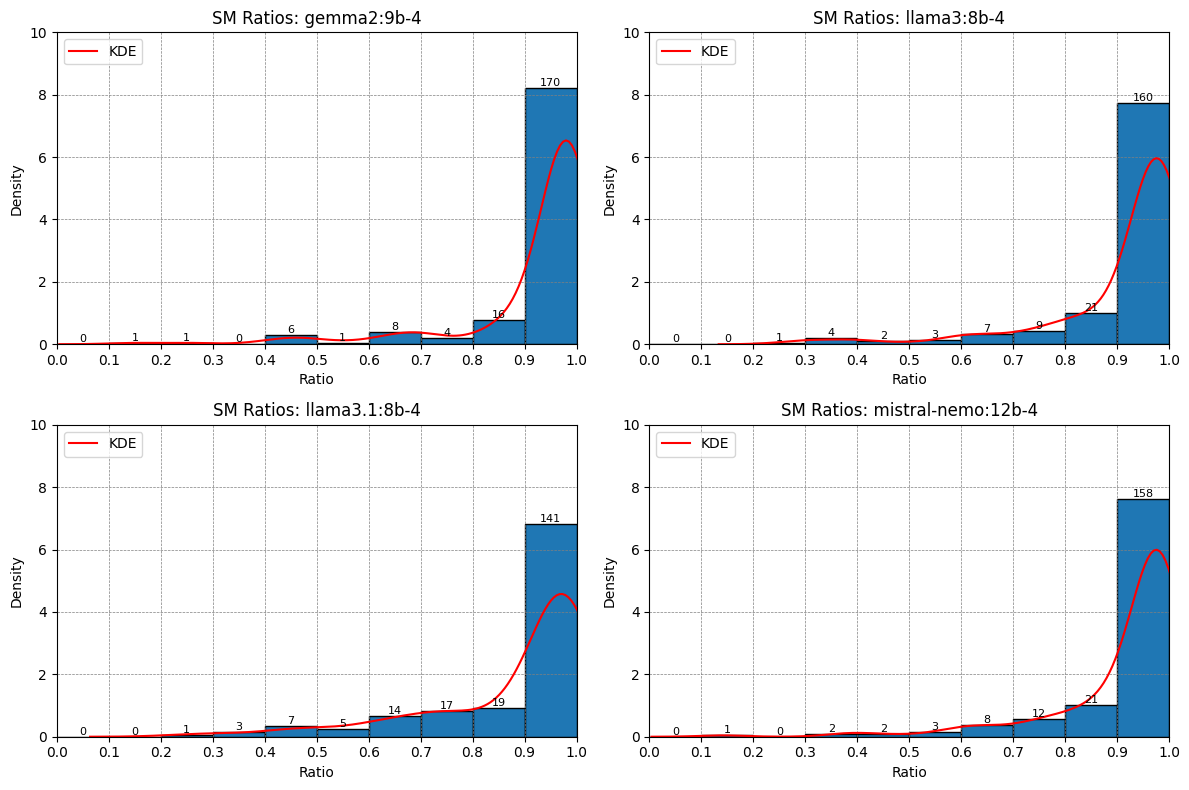

In [40]:
fig, ax = multi_histogram(res, "sm_similarity_ratios", "SM Ratios", "upper left")

#### Levenshtein Distance Ratios

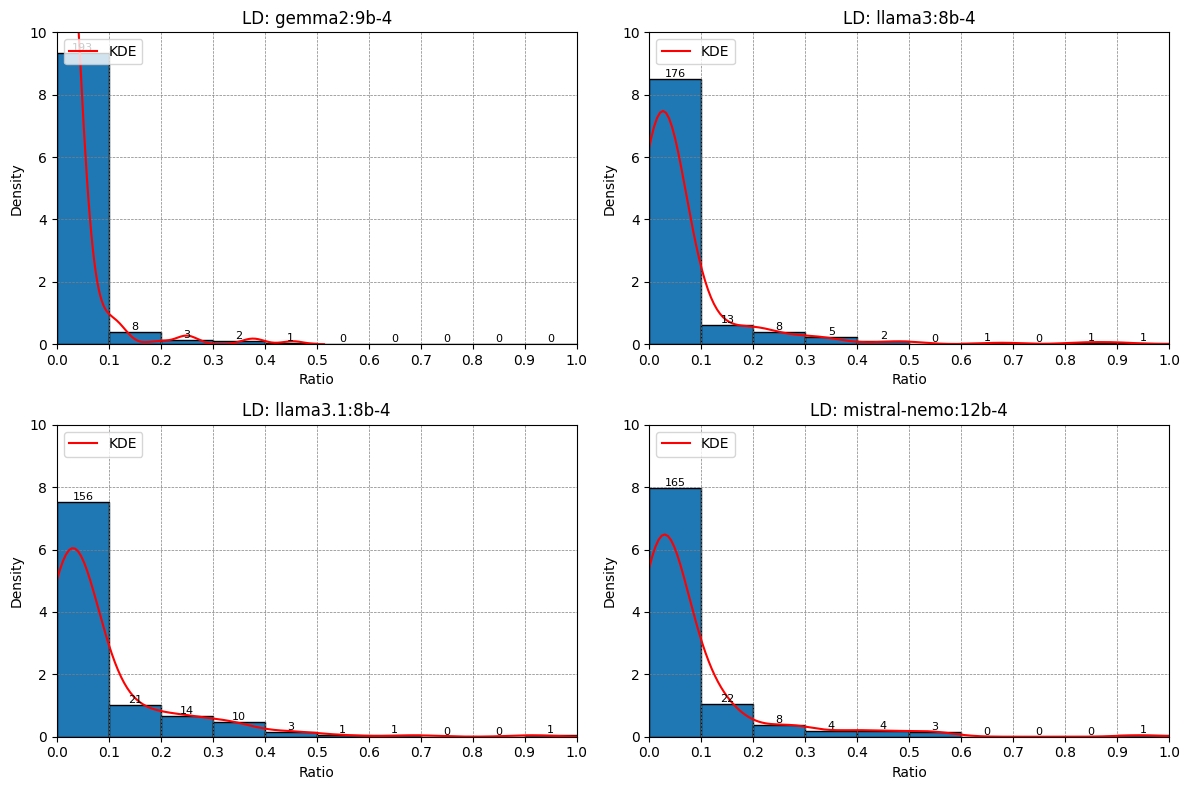

In [41]:
fig, ax = multi_histogram(res, "levenshtein_distance_ratios", "LD", "upper left")

#### ALL

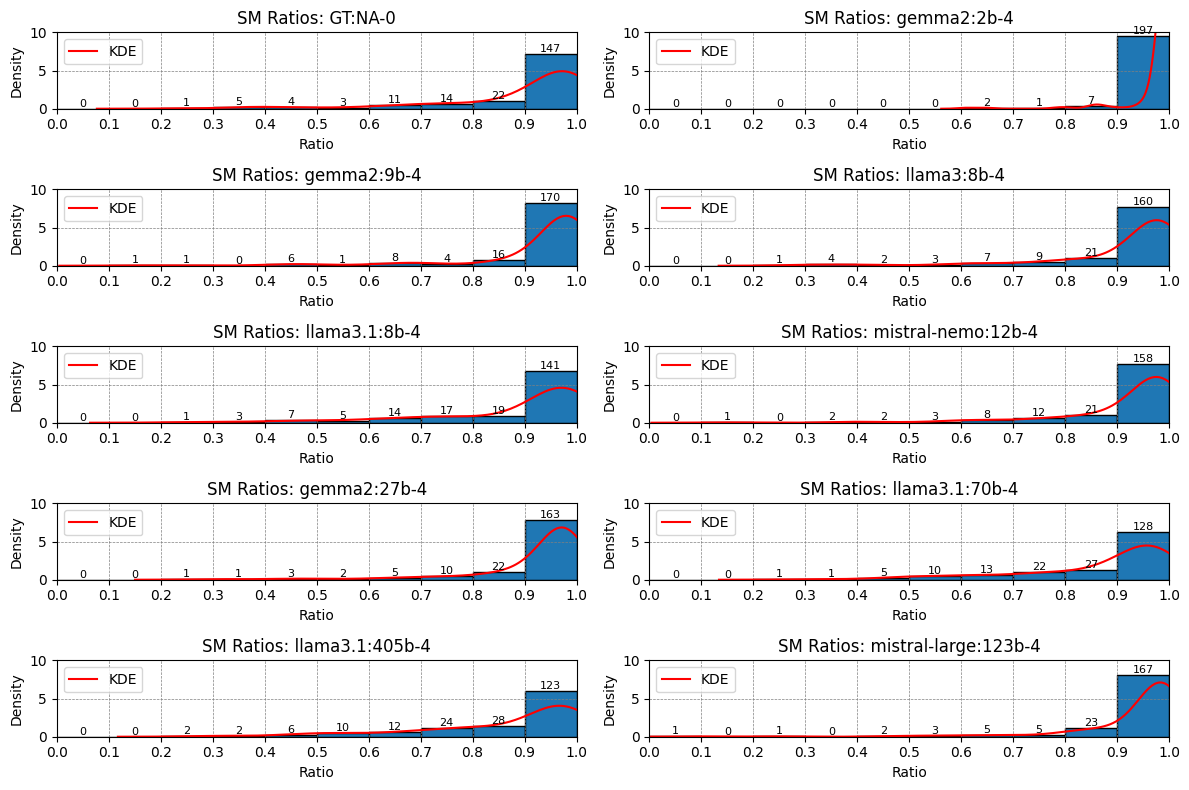

In [42]:
fig, ax = multi_histogram(gt_res + res_all, "sm_similarity_ratios", "SM Ratios", "upper left")

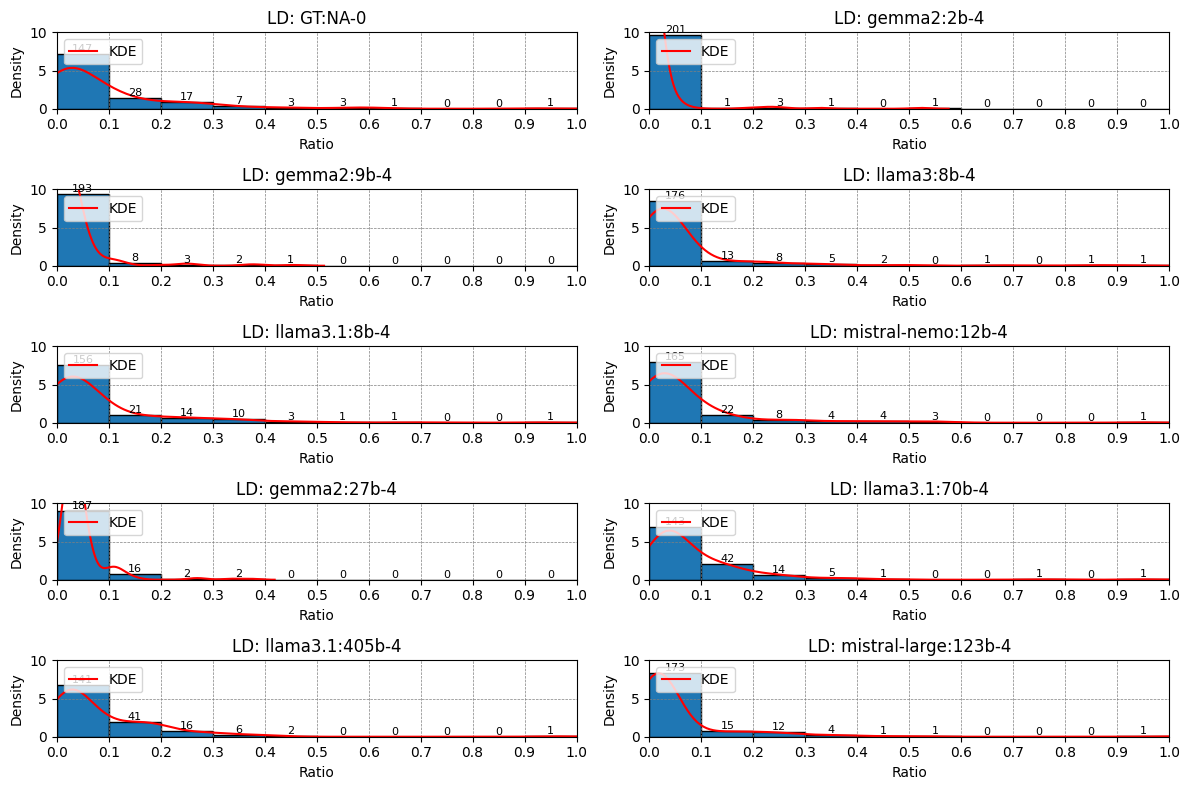

In [43]:
fig, ax = multi_histogram(gt_res + res_all, "levenshtein_distance_ratios", "LD", "upper left")

### LanguageTool Metrics

#### Spell Check

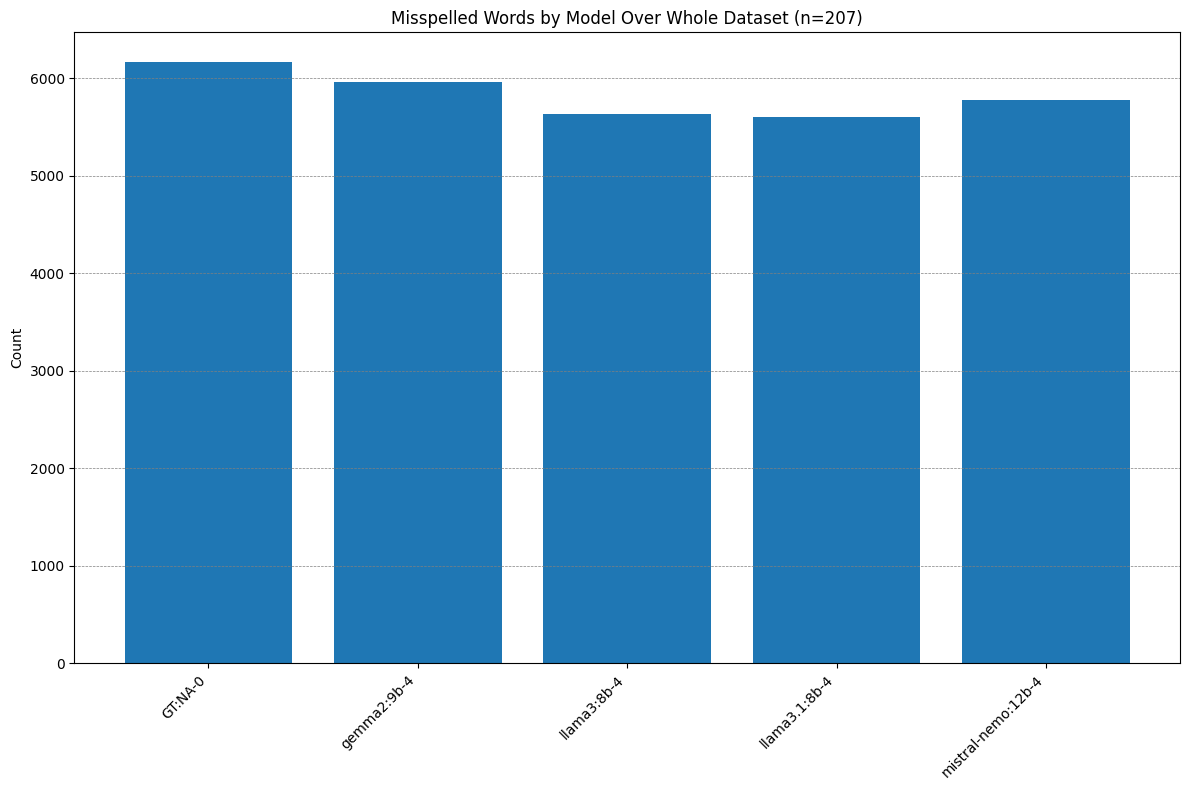

In [44]:
fig, ax = multi_bar_graph(gt_res + res, "misspelled", "Misspelled Words by Model Over Whole Dataset (n=207)")

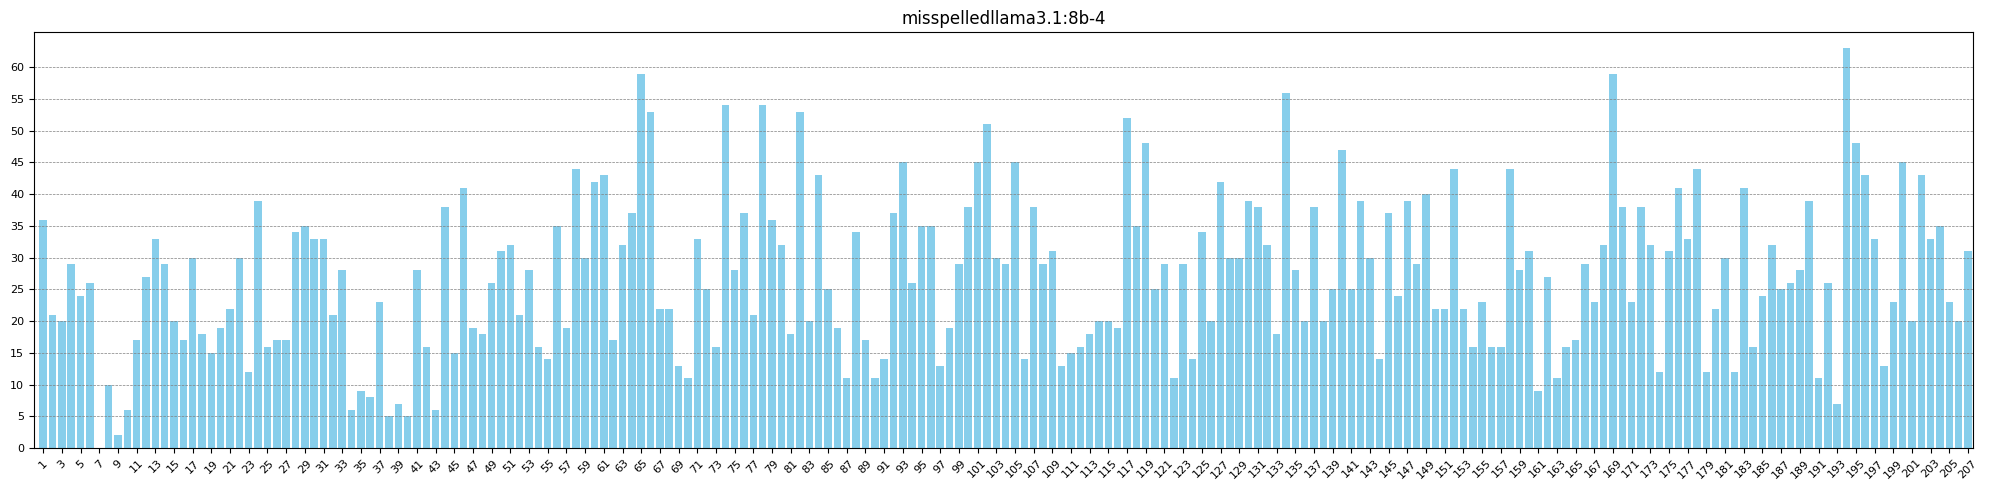

In [45]:
fig, ax = multi_bar_model_graph(res[2], "misspelled", 5)

#### ALL

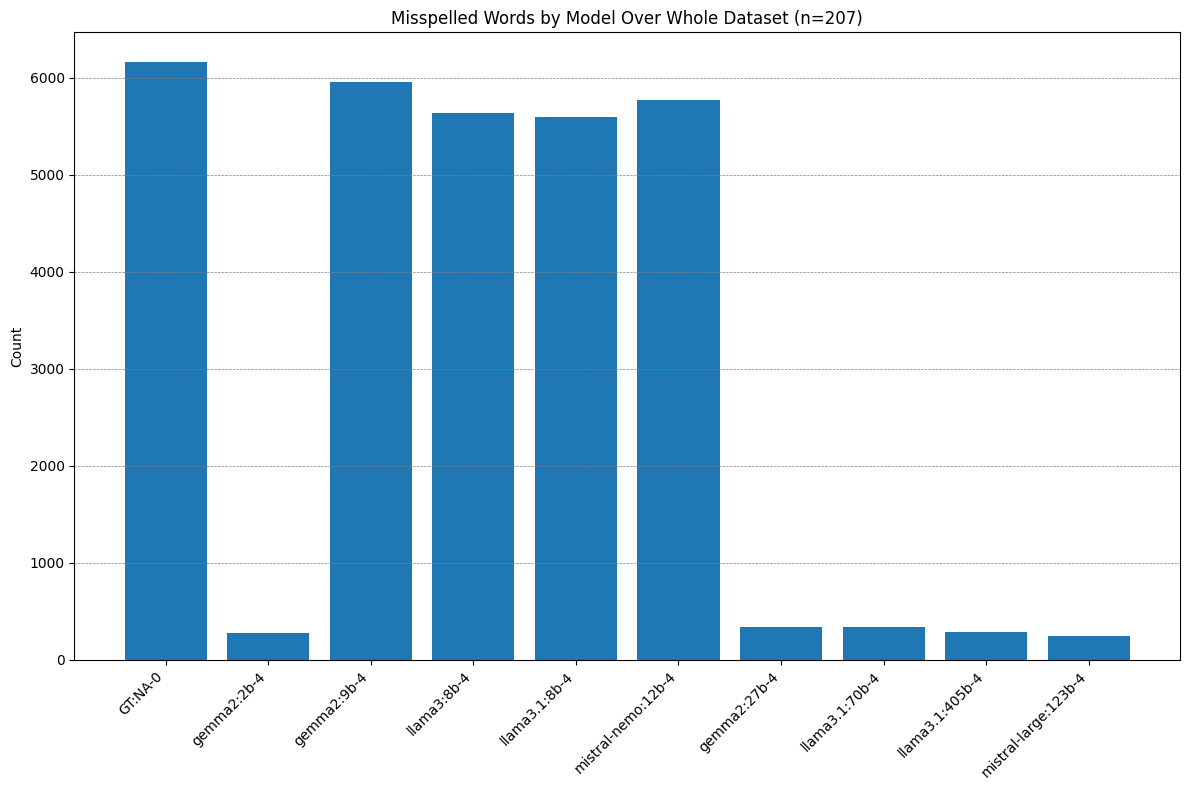

In [46]:
fig, ax = multi_bar_graph(gt_res + res_all, "misspelled", "Misspelled Words by Model Over Whole Dataset (n=207)")

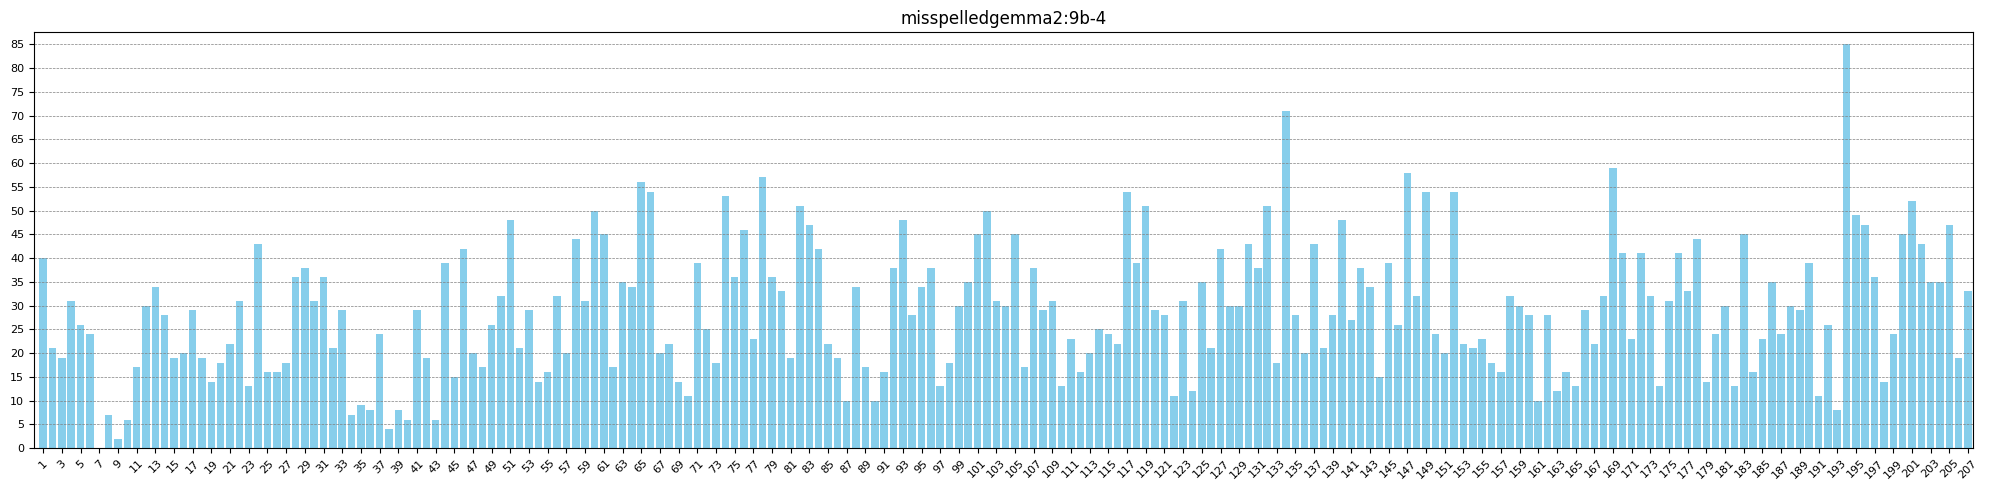

In [47]:
fig, ax = multi_bar_model_graph(res[0], "misspelled", 5)

#### Grammar Check

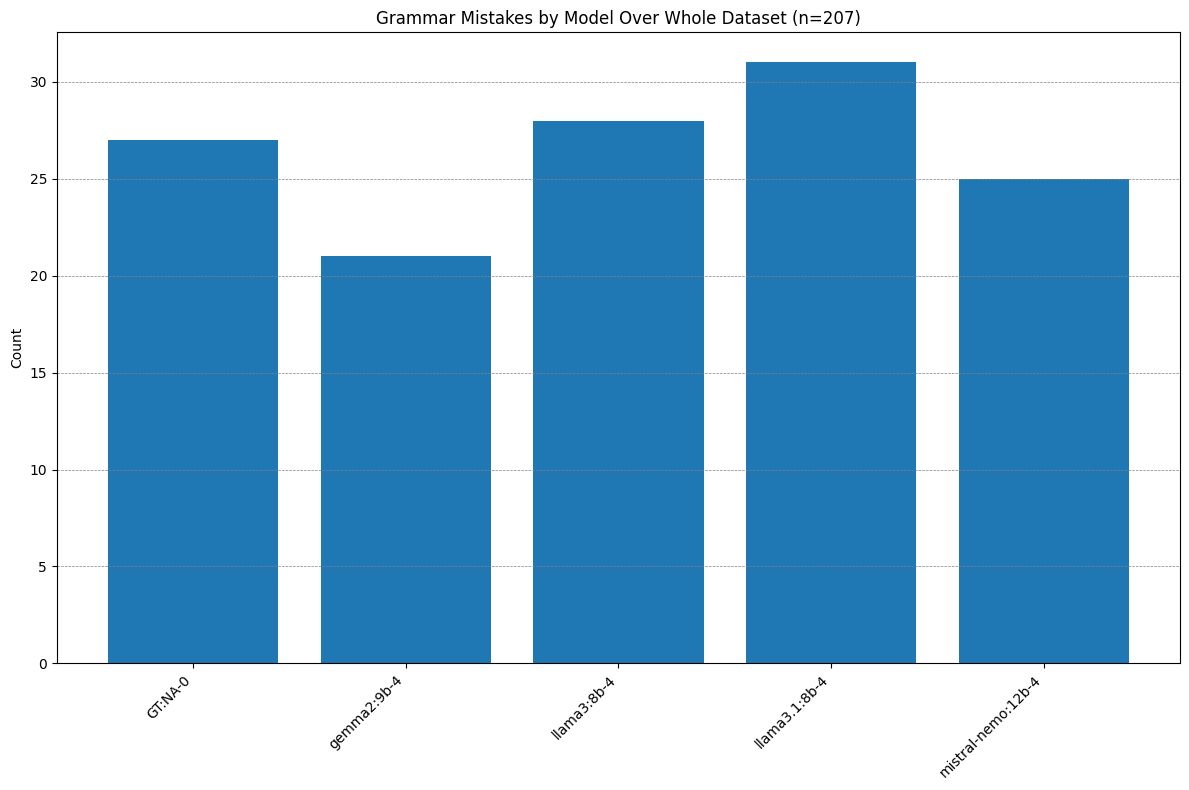

In [48]:
fig, ax = multi_bar_graph(gt_res + res, "grammer", "Grammar Mistakes by Model Over Whole Dataset (n=207)")

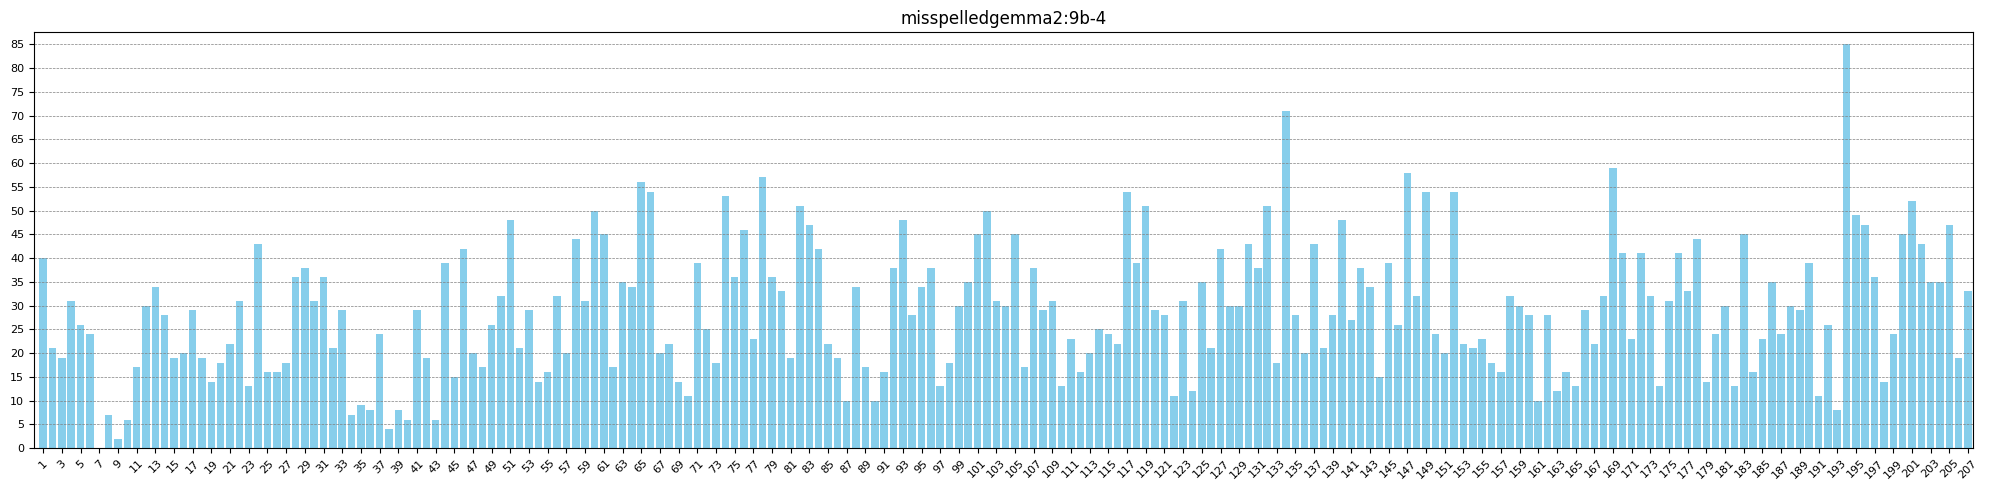

In [49]:
fig, ax = multi_bar_model_graph(res[0], "misspelled", 5)

#### ALL

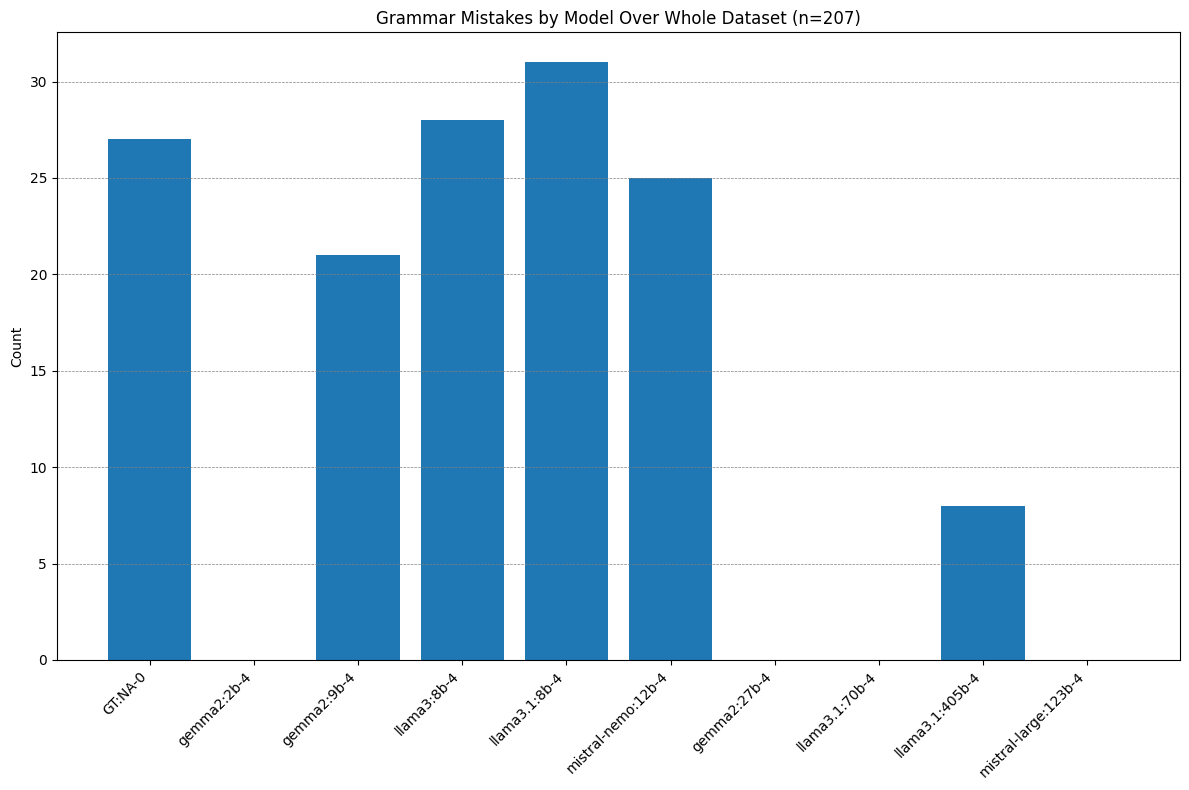

In [50]:
fig,ax = multi_bar_graph(gt_res + res_all, "grammer", "Grammar Mistakes by Model Over Whole Dataset (n=207)")

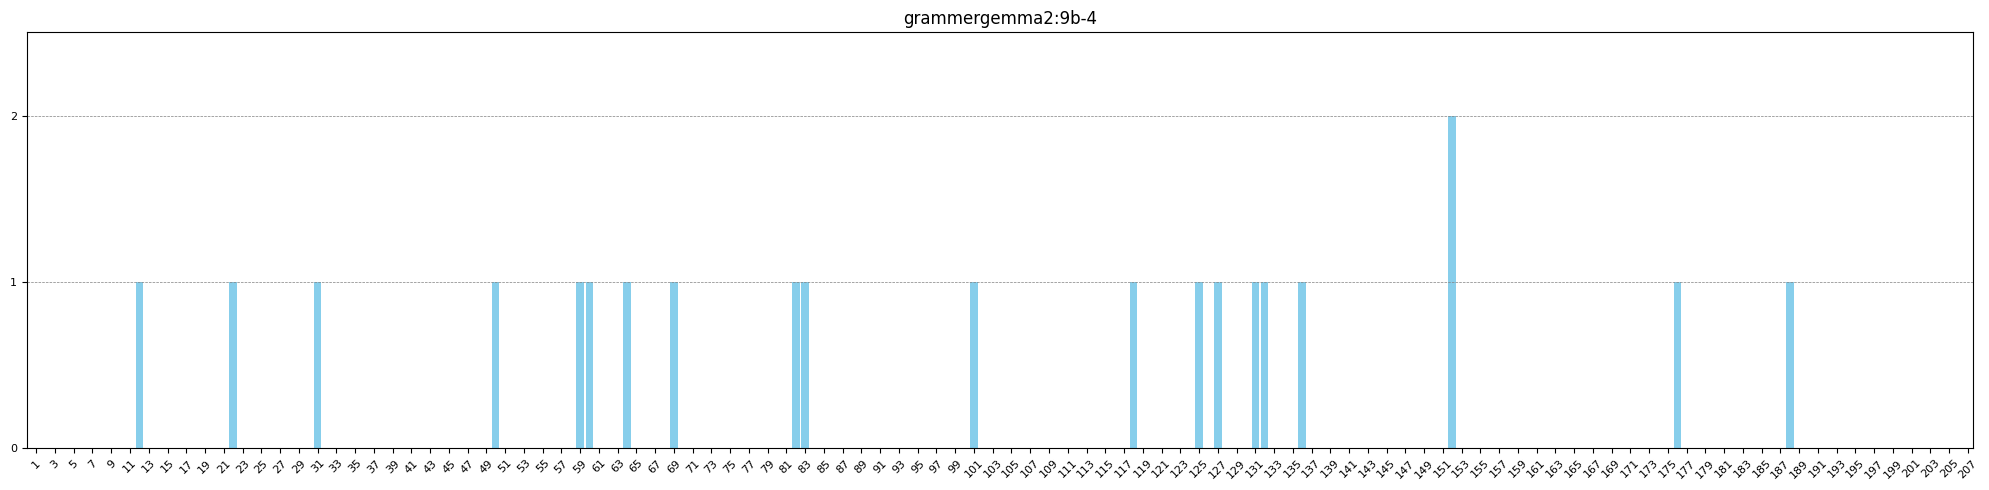

In [51]:
fig, ax = multi_bar_model_graph(res[0], "grammer", 1)

### Semantics Metrics

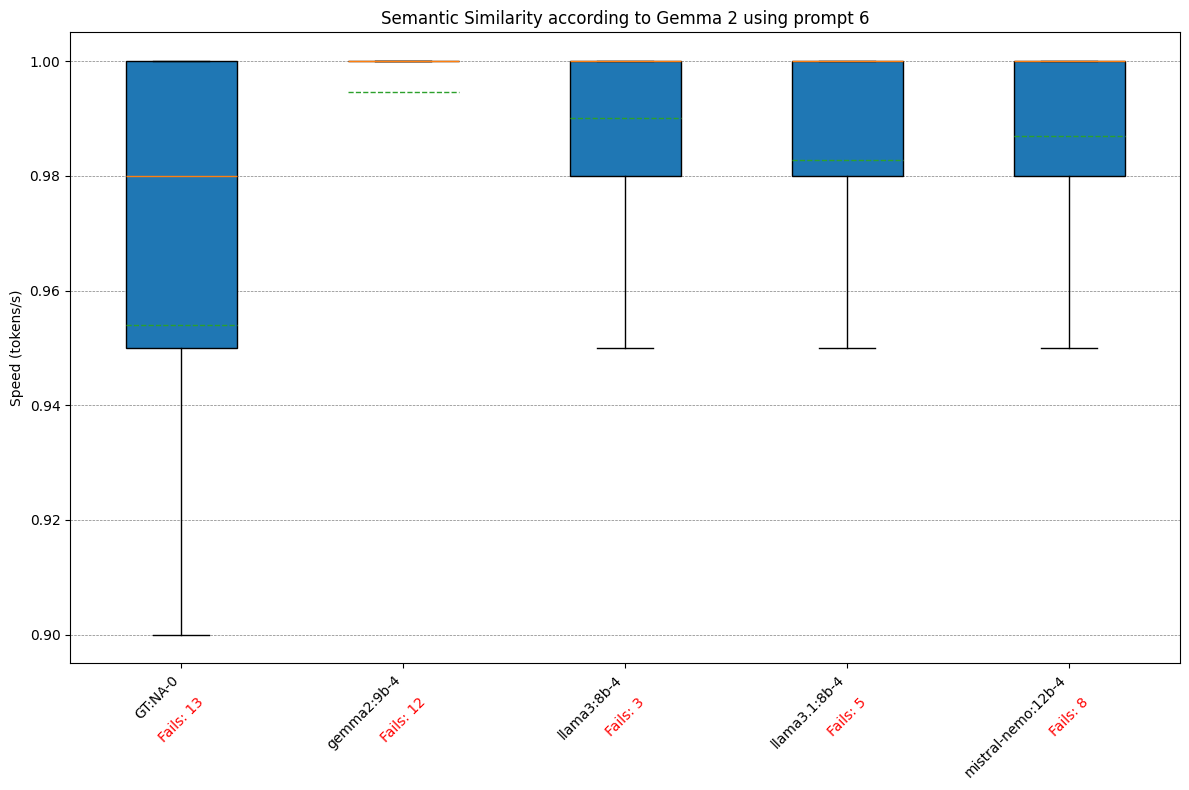

In [52]:
fig, ax = semantic_box_plot(gt_res + res)

### Violin Plot

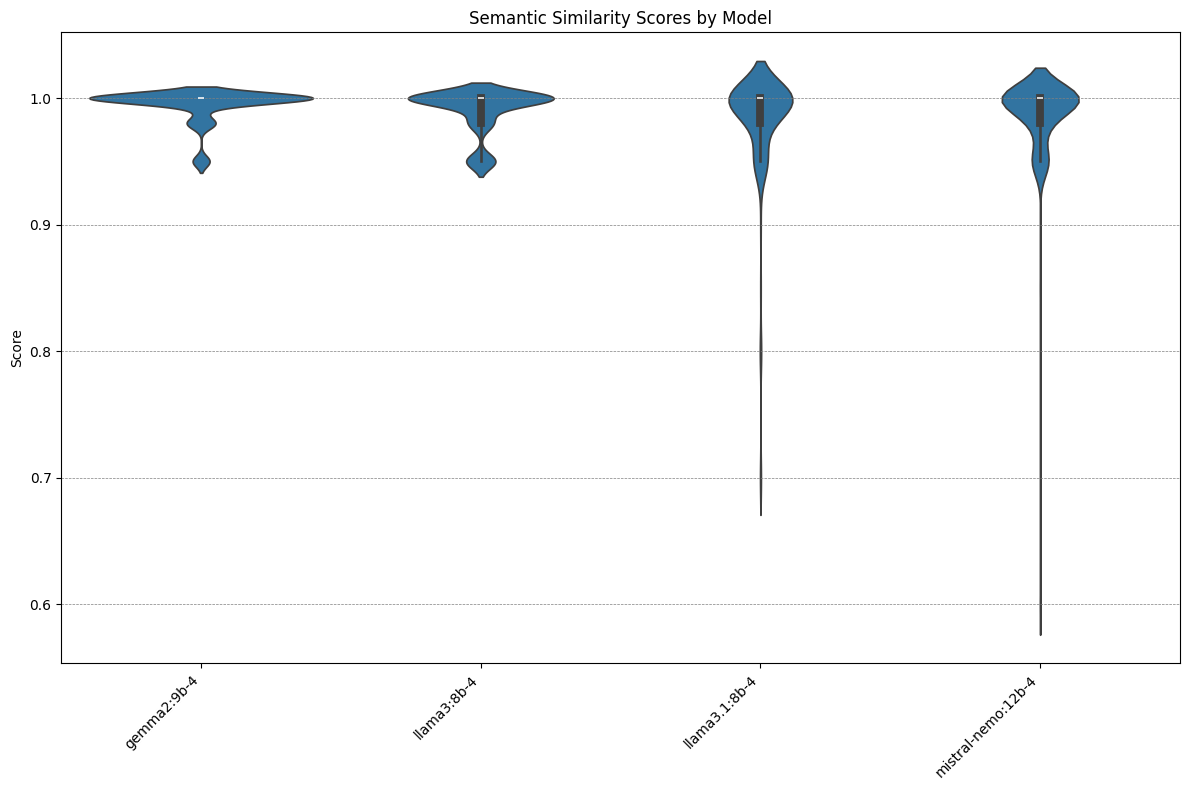

In [53]:
fig, ax = violin_plot(res)